# Explainability & Governance

**Enterprise-Grade Recommendation System with Deep Learning**  
*Domain: E-Commerce / Retail*

---

Why each recommendation was made, whether the system treats customer groups equitably, and where it fails. A recommender that cannot be interrogated cannot be deployed responsibly.

## Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project modules importable from the notebooks folder.
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))
sys.path.append(os.path.join(BASE_DIR, "models"))

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Project root:", BASE_DIR)

Project root: E:\Recommendation_System_Final


## 1. Load the recommender

In [2]:
from hybrid_recommender import HybridRecommender
from explainability import (attribute_signals, explain_recommendation,
    explain_via_similar_items, explain_via_similar_users,
    render_similar_user_evidence, explain_content_similarity,
    explain_similar_item, build_full_explanation)

recommender = HybridRecommender.load()
print('Fusion weights:', recommender.weights)

Fusion weights: {'item_cf': 0.45, 'collaborative': 0.1, 'content': 0.1, 'ncf': 0.35}


## 2. The three mandated explanation types

The business case requires the system to explain **why an item is recommended**, **which similar users or items support it**, and **what content similarity justifies it**.

The design principle throughout: every explanation is derived from the *actual scores that produced the ranking*, never from a plausible-sounding template. A generated sentence that does not correspond to the real reason is worse than no explanation - it manufactures false confidence and will eventually contradict the model in front of a customer.

In [3]:
user_id = int(recommender.interactions_df['user_id'].value_counts().index[0])
profile = recommender.user_details(user_id)
recs = recommender.recommend(user_id, top_n=5)

print('Customer #{} - {}, prefers {}, {} interactions\n'.format(
    user_id, profile['user_segment'], profile['preferred_category'],
    recommender.user_interaction_count(user_id)))

row = recs.iloc[0]
print('Recommended: {} (INR {:,.0f})\n'.format(row['title'], row['price']))
print('[1] WHY THIS ITEM')
print(' ', explain_recommendation(recommender, user_id, row))

Customer #3181 - Luxury Enthusiast, prefers Sports & Outdoors, 201 interactions

Recommended: Lumitek Compact Headphone 928 (INR 3,217)

[1] WHY THIS ITEM
  Recommended because it is bought alongside products you have already rated highly (driving 51% of this recommendation); the neural model predicts a strong preference from your interaction pattern.


### Signal attribution

Reporting raw per-signal scores would mislead: a signal with a high score but a low fusion weight contributes little to the final ranking. What matters is weight x score - the share of the decision each signal is genuinely responsible for.

,signal,raw_score,weight,contribution,contribution_share
0,item-based collaborative filtering,1.000000,0.45,0.450000,0.513150
1,the deep learning model,0.970521,0.35,0.339682,0.387351
2,latent-factor collaborative filtering,0.638963,0.10,0.063896,0.072863
3,content similarity,0.233574,0.10,0.023357,0.026635


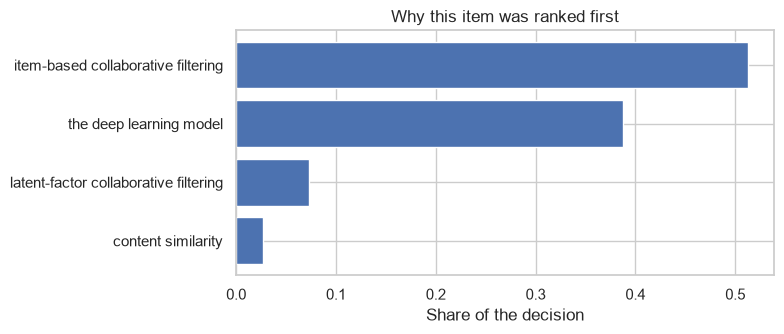

In [4]:
attribution = attribute_signals(row, recommender.weights)
display(attribution)

plt.figure(figsize=(8, 3.5))
plt.barh(attribution['signal'], attribution['contribution_share'], color='#4C72B0')
plt.xlabel('Share of the decision')
plt.title('Why this item was ranked first')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

In [5]:
print('[2] EVIDENCE - the customer\'s own comparable purchases')
evidence = explain_via_similar_items(recommender, user_id, int(row['item_id']))
display(evidence)

print('\n[3] EVIDENCE - similar customers')
neighbours = explain_via_similar_users(recommender, user_id, int(row['item_id']))
print(' ', render_similar_user_evidence(neighbours))

[2] EVIDENCE - the customer's own comparable purchases


,item_id,title,category,similarity
0,1729,Lumitek Everyday Smartphone 253,Electronics,0.3252
1,1437,Volante Compact Headphone 207,Electronics,0.3060
2,1757,Byteforge Everyday Headphone 508,Electronics,0.2439



[3] EVIDENCE - similar customers
  14 of the 19 closest customer matches who rated this item scored it 4 or above (mean 4.0), out of 50 neighbours considered.


**An honest tension worth naming.** Similar-customer evidence is often empty, and the reason is structural rather than a defect: the re-ranker deliberately promotes under-exposed long-tail items, and an item is long-tail precisely because few people have interacted with it. **The diversity mechanism actively erodes the collaborative evidence available to justify its own output.**

The system states this plainly rather than concealing it. A customer told 'customers like you loved this' about an item no comparable customer has ever rated is being misled.

In [6]:
print('[4] CONTENT JUSTIFICATION')
if not evidence.empty:
    source = int(evidence.iloc[0]['item_id'])
    detail = explain_content_similarity(recommender, source, int(row['item_id']))
    print('  similarity        :', detail['similarity'])
    print('  shared attributes :', detail['shared_attributes'])
    print('  shared tags       :', detail['shared_tags'])
    print('  matching terms    :', detail['shared_terms'])
    print('\n ', explain_similar_item(recommender, source, int(row['item_id'])))

[4] CONTENT JUSTIFICATION
  similarity        : 0.3252
  shared attributes : ['category: Electronics', 'brand: Lumitek']
  shared tags       : ['bluetooth', 'high-resolution']
  matching terms    : ['bluetooth high', 'lumitek', 'bluetooth', 'resolution', 'high resolution']

  Content similarity to 'Lumitek Everyday Smartphone 253' is 0.33; shared category: Electronics, brand: Lumitek; common attributes: bluetooth, high-resolution; matching description terms: bluetooth high, lumitek, bluetooth, resolution.


Exposing the actual TF-IDF terms is what converts 'similarity 0.83' into something a merchandiser can audit. If the shared terms turn out to be filler vocabulary rather than meaningful product attributes, that is a defect in the text representation - and this is how it gets caught.

## 3. Cold-start explanations must be different

A new customer gets a visibly different and honest explanation, not the same confident sentence with different nouns.

In [7]:
counts = recommender.users_df['user_id'].map(recommender.user_interaction_count)
cold_user = int(recommender.users_df.loc[counts < 3, 'user_id'].iloc[0])
cold_profile = recommender.user_details(cold_user)

print('Customer #{} - {}, prefers {}, {} interactions\n'.format(
    cold_user, cold_profile['user_segment'], cold_profile['preferred_category'],
    recommender.user_interaction_count(cold_user)))

cold_recs = recommender.recommend(cold_user, top_n=3)
print('Strategy:', cold_recs['strategy'].iloc[0], '\n')
for _, r in cold_recs.iterrows():
    print('-', r['title'], '(INR {:,.0f})'.format(r['price']))
    print('  ', explain_recommendation(recommender, cold_user, r), '\n')

Customer #18 - Budget Shopper, prefers Automotive, 2 interactions

Strategy: cold_start_user_profile 

- Torqline Advanced Lubricant 987 (INR 326)
   You are new here, so this is based on your registration profile rather than purchase history: it sits in Automotive, the category you selected, and is priced at INR 326, which fits the typical Budget Shopper budget. Recommendations will become personalised once you have browsed a few items. 

- Pistonworks Elite Tyre 177 (INR 270)
   You are new here, so this is based on your registration profile rather than purchase history: it sits in Automotive, the category you selected, and is priced at INR 270, which fits the typical Budget Shopper budget. Recommendations will become personalised once you have browsed a few items. 

- Gearhaus Lite Car Care 214 (INR 401)
   You are new here, so this is based on your registration profile rather than purchase history: it sits in Automotive, the category you selected, and is priced at INR 401, which fi

## 4. Governance: does the system treat customer groups equitably?

Recommendation systems allocate visibility. If quality varies systematically by segment or demographic, some customers receive a materially worse service than others.

In [8]:
import numpy as np

rng = np.random.default_rng(42)
active = counts[counts >= 5].index.tolist()
cohort = rng.choice(active, size=min(240, len(active)), replace=False)

rows = []
for uid in cohort:
    uid = int(uid)
    r = recommender.recommend(uid, top_n=10)
    if r.empty:
        continue
    p = recommender.user_details(uid)
    rows.append({
        'user_id': uid,
        'segment': p['user_segment'],
        'gender': p['gender'],
        'age': p['age'],
        'interactions': recommender.user_interaction_count(uid),
        'strategy': r['strategy'].iloc[0],
        'mean_price': r['price'].mean(),
        'categories': r['category'].nunique(),
        'long_tail': r['is_long_tail'].mean() if 'is_long_tail' in r.columns else np.nan,
    })

audit = pd.DataFrame(rows)
print('Audited {} customers'.format(len(audit)))
audit.head()

Audited 240 customers


,user_id,segment,gender,age,interactions,strategy,mean_price,categories,long_tail
0,526,Value Seeker,Female,18,16,hybrid_fusion,1917.749,4,0.0
1,4631,Value Seeker,Female,21,3,hybrid_fusion,1160.686,2,0.1
2,5706,Value Seeker,Female,32,22,hybrid_fusion,1284.042,5,0.0
3,4501,Budget Shopper,Female,19,6,hybrid_fusion,743.952,4,0.0
4,4698,Value Seeker,Male,18,4,hybrid_fusion,1500.100,1,0.0


### Price fairness across segments

The key question: is the system steering budget-conscious customers toward cheap goods so persistently that they never see anything better - a filter bubble with commercial consequences?

,customers,mean_recommended_price,category_diversity,long_tail_share
segment,,,,
Budget Shopper,63,1466.35,3.02,0.02
Mainstream Buyer,56,1894.36,2.80,0.00
Value Seeker,71,2155.51,3.24,0.01
Premium Buyer,32,2820.25,3.16,0.03
Luxury Enthusiast,18,3495.65,3.06,0.00


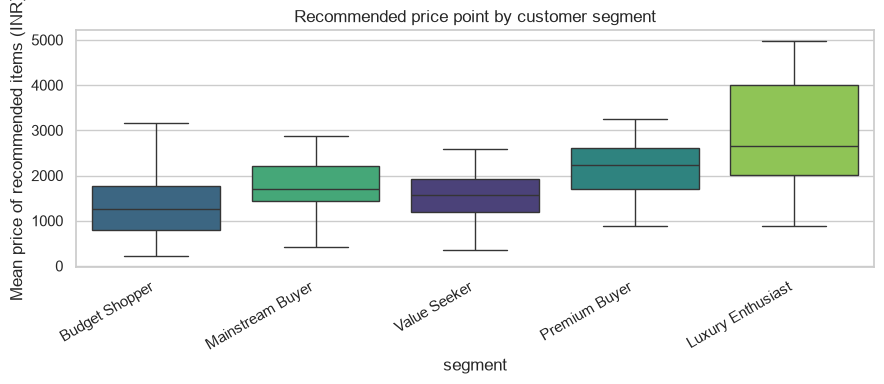

In [9]:
by_segment = audit.groupby('segment').agg(
    customers=('user_id', 'count'),
    mean_recommended_price=('mean_price', 'mean'),
    category_diversity=('categories', 'mean'),
    long_tail_share=('long_tail', 'mean'),
).round(2).sort_values('mean_recommended_price')
display(by_segment)

plt.figure(figsize=(9, 4))
sns.boxplot(data=audit, x='segment', y='mean_price',
            order=by_segment.index.tolist(), hue='segment',
            legend=False, palette='viridis', showfliers=False)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Mean price of recommended items (INR)')
plt.title('Recommended price point by customer segment')
plt.tight_layout(); plt.show()

Price differentiation across segments is *intended* - it reflects genuine purchasing behaviour, and recommending a INR 90,000 item to a budget shopper serves nobody. The governance question is whether the gap is proportionate to observed behaviour or amplified beyond it. That comparison is made in `reports/governance_and_fairness.md`.

### Demographic parity check

In [10]:
by_gender = audit.groupby('gender').agg(
    customers=('user_id', 'count'),
    mean_price=('mean_price', 'mean'),
    category_diversity=('categories', 'mean'),
).round(2)
display(by_gender)

spread = by_gender['category_diversity'].max() - by_gender['category_diversity'].min()
print('Category-diversity spread across gender: {:.2f}'.format(spread))
print('Gender is not a model input - any gap here comes from correlated behaviour.')

,customers,mean_price,category_diversity
gender,,,
Female,131,2114.66,3.03
Male,101,2050.77,3.01
Other,8,2565.90,4.00


Category-diversity spread across gender: 0.99
Gender is not a model input - any gap here comes from correlated behaviour.


### Service quality by activity level

The most consequential fairness axis in any recommender. Light users get worse recommendations *and* are the least likely to tolerate them.

In [11]:
audit['activity_band'] = pd.cut(audit['interactions'], [0, 10, 25, 60, 10000],
                                labels=['5-10', '11-25', '26-60', '60+'])

by_activity = audit.groupby('activity_band', observed=True).agg(
    customers=('user_id', 'count'),
    category_diversity=('categories', 'mean'),
    long_tail_share=('long_tail', 'mean'),
).round(3)
display(by_activity)

,customers,category_diversity,long_tail_share
activity_band,,,
5-10,94,2.372,0.039
11-25,75,3.427,0.000
26-60,48,3.479,0.000
60+,19,4.316,0.000


## 5. Where the system fails

Stating the limitations plainly is part of governance, not a caveat bolted on at the end.

| Failure mode | Cause | Mitigation in place |
|---|---|---|
| Empty crowd evidence for long-tail items | diversity boost promotes items few have rated | disclosed in the explanation text |
| Explicit NCF cannot rank | trained only on observed pairs | production ranks with the implicit variant |
| User-user CF will not scale | O(users^2) memory | ANN index recommended beyond ~50k users |
| Cold-start quality is unverifiable | no ground truth for users with no history | offline proxy only; needs an online A/B test |
| Popularity feedback loop | recommending popular items makes them more popular | inverse-propensity penalty, alpha = 0.20 |

### On the synthetic data itself

Every number in this project comes from generated data. The models have learned the rules the generator was written with - category affinity and segment price sensitivity - and the reported metrics measure how well those specific rules were recovered. **No claim is made that these numbers would hold on real customer data.** What the project demonstrates is that the pipeline, the evaluation methodology, and the serving architecture are sound, which is exactly what the brief asks for when real data is unavailable.